# The End — Analisi Integrata: Anomalie Termiche → Proprietà Meccaniche

Questo notebook unisce i risultati dei due notebook precedenti:
- **`conformal.ipynb`** → Anomalie termiche rilevate durante la stampa 3D (Conformal Prediction)
- **`tracking_allungamento.ipynb`** → Proprietà meccaniche misurate nella prova di flessione sotto carico

**Obiettivo finale:** Capire se le anomalie termiche osservate *durante la stampa* possono predire la fragilità e il carico di rottura del pezzo stampato.

---
## 1. Import e Caricamento Dati

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Percorsi
CONF_DIR = os.path.join("dati", "dataset_finale", "conformal")
MECH_DIR = os.path.join("dati", "dataset_finale", "meccanica")
ALIGNED_DIR = os.path.join("dati", "mini_video_allineati")

# --- Dati Conformal ---
CONF_DIR = os.path.join("dati", "dataset_finale", "conformal_resampled_phase")
mean_model = np.load(os.path.join(CONF_DIR, "mean_model.npy"))
calib_scores = np.load(os.path.join(CONF_DIR, "calib_scores.npy"))
df_anomaly_counts = pd.read_csv(os.path.join(CONF_DIR, "anomaly_counts.csv"))
df_anomaly_summary = pd.read_csv(os.path.join(CONF_DIR, "anomaly_summary.csv"))
# --- Dati Meccanici ---
df_mech = pd.read_csv(os.path.join(MECH_DIR, "mechanical_properties.csv"))
df_elong = pd.read_csv(os.path.join(MECH_DIR, "elongation_table.csv"))
df_verif = pd.read_csv(os.path.join(MECH_DIR, "load_verification.csv"))

# Converti provino_id a stringa ovunque
for df in [df_anomaly_counts, df_anomaly_summary, df_mech, df_elong, df_verif]:
    id_col = 'provino_id' if 'provino_id' in df.columns else 'Provino'
    df[id_col] = df[id_col].astype(str)

print("=" * 60)
print("DATI CARICATI CON SUCCESSO")
print("=" * 60)
print(f"Modello medio:        {mean_model.shape} (frames, H, W)")
print(f"Score calibrazione:   {calib_scores.shape} (n_calib, frames, H, W)")
print(f"Anomaly counts:       {len(df_anomaly_counts)} righe (passate totali)")
print(f"Anomaly summary:      {len(df_anomaly_summary)} provini")
print(f"Proprietà meccaniche: {len(df_mech)} provini")
print(f"Tabella allungamenti: {len(df_elong)} provini")
print(f"Verifica carichi:     {len(df_verif)} provini")
print(f"Mini-video allineati: {len(os.listdir(ALIGNED_DIR))} cartelle provino")

DATI CARICATI CON SUCCESSO
Modello medio:        (16, 30, 68) (frames, H, W)
Score calibrazione:   (47, 16, 30, 68) (n_calib, frames, H, W)
Anomaly counts:       1073 righe (passate totali)
Anomaly summary:      11 provini
Proprietà meccaniche: 11 provini
Tabella allungamenti: 11 provini
Verifica carichi:     12 provini
Mini-video allineati: 0 cartelle provino


---
## 2. Dati Conformal — Anomalie Termiche

### 2.1 Riepilogo Anomalie per Provino
La tabella `anomaly_summary` mostra per ogni provino le statistiche aggregate (media, max, totale, deviazione standard) del numero di pixel anomali calcolate su tutte le passate, a diversi livelli di p-value.

In [2]:
display(df_anomaly_summary)

,provino_id,n_passate,mean_anomaly_pv0.01,max_anomaly_pv0.01,total_anomaly_pv0.01,std_anomaly_pv0.01,mean_anomaly_fraction_pv0.01,max_anomaly_fraction_pv0.01,total_anomaly_fraction_pv0.01,std_anomaly_fraction_pv0.01,...,total_active_phase_fraction_pv0.5,std_active_phase_fraction_pv0.5,mean_auc_anomaly_fraction_pv0.5,max_auc_anomaly_fraction_pv0.5,total_auc_anomaly_fraction_pv0.5,std_auc_anomaly_fraction_pv0.5,mean_max_phase_anomaly_fraction_pv0.5,max_max_phase_anomaly_fraction_pv0.5,total_max_phase_anomaly_fraction_pv0.5,std_max_phase_anomaly_fraction_pv0.5
0,101,200,8084.765000,18747,1616953,6997.492845,0.247695,0.574357,49.539001,0.214384,...,200.0000,0.00000,10.105805,13.559804,2021.161029,3.590532,0.734468,0.935784,146.893627,0.215970
1,102,76,996.394737,7259,75726,1976.580577,0.030527,0.222396,2.320037,0.060557,...,76.0000,0.00000,5.636749,10.424755,428.392892,2.913473,0.469846,0.818137,35.708333,0.201199
2,301,75,2563.093333,13984,192232,3991.798742,0.078526,0.428431,5.889461,0.122298,...,75.0000,0.00000,7.513007,12.550980,563.475490,3.344086,0.585673,0.872549,43.925490,0.212274
3,302,83,3903.879518,18959,324022,5597.157348,0.119604,0.580852,9.927145,0.171482,...,83.0000,0.00000,8.856257,14.098284,735.069363,3.495656,0.670435,0.973529,55.646078,0.208743
4,303,76,3384.315789,15605,257208,5000.031478,0.103686,0.478094,7.880147,0.153187,...,76.0000,0.00000,7.904925,13.966912,600.774265,3.642515,0.605347,0.948529,46.006373,0.224707
5,304,76,3327.657895,15297,252902,4865.130372,0.101950,0.468658,7.748223,0.149054,...,76.0000,0.00000,7.947923,13.827696,604.042157,3.633079,0.614061,0.934314,46.668627,0.218109
6,601,87,6166.609195,18684,536495,5427.265797,0.188928,0.572426,16.436734,0.166277,...,87.0000,0.00000,10.107268,14.326961,879.332353,3.085815,0.740872,0.970588,64.455882,0.186621
7,602,80,6839.800000,25784,547184,8810.625449,0.209553,0.789951,16.764216,0.269933,...,80.0000,0.00000,9.659047,14.870588,772.723775,3.706403,0.704773,0.998529,56.381863,0.219966
8,901,82,6407.000000,24515,525374,7395.618700,0.196293,0.751072,16.096017,0.226581,...,82.0000,0.00000,10.123655,14.913725,830.139706,3.253760,0.736358,0.997549,60.381373,0.191323
9,902,79,8225.253165,29227,649795,10024.798802,0.251999,0.895435,19.907935,0.307132,...,79.0000,0.00000,9.939241,14.940441,785.200000,3.460185,0.724541,1.000000,57.238725,0.199253


### 2.2 Dettaglio Anomalie per Passata
Le prime righe della tabella `anomaly_counts`: per ogni provino e passata (stroke), il numero di pixel anomali a ciascun p-value.

In [3]:
print(f"Colonne: {list(df_anomaly_counts.columns)}")
display(df_anomaly_counts.head(15))

Colonne: ['provino_id', 'stroke_file', 'stroke_idx', 'model_input_dir', 'n_elements', 'n_pixels_per_phase', 'original_length', 'target_length', 'compression_factor', 'anomaly_pv0.01', 'anomaly_fraction_pv0.01', 'excess_sum_pv0.01', 'excess_mean_all_pv0.01', 'excess_mean_anom_pv0.01', 'cold_deficit_sum_pv0.01', 'cold_deficit_mean_all_pv0.01', 'cold_deficit_mean_anom_pv0.01', 'active_phase_count_pv0.01', 'active_phase_fraction_pv0.01', 'auc_anomaly_fraction_pv0.01', 'max_phase_anomaly_fraction_pv0.01', 'anomaly_pv0.02', 'anomaly_fraction_pv0.02', 'excess_sum_pv0.02', 'excess_mean_all_pv0.02', 'excess_mean_anom_pv0.02', 'cold_deficit_sum_pv0.02', 'cold_deficit_mean_all_pv0.02', 'cold_deficit_mean_anom_pv0.02', 'active_phase_count_pv0.02', 'active_phase_fraction_pv0.02', 'auc_anomaly_fraction_pv0.02', 'max_phase_anomaly_fraction_pv0.02', 'anomaly_pv0.05', 'anomaly_fraction_pv0.05', 'excess_sum_pv0.05', 'excess_mean_all_pv0.05', 'excess_mean_anom_pv0.05', 'cold_deficit_sum_pv0.05', 'cold_de

,provino_id,stroke_file,stroke_idx,model_input_dir,n_elements,n_pixels_per_phase,original_length,target_length,compression_factor,anomaly_pv0.01,...,excess_sum_pv0.5,excess_mean_all_pv0.5,excess_mean_anom_pv0.5,cold_deficit_sum_pv0.5,cold_deficit_mean_all_pv0.5,cold_deficit_mean_anom_pv0.5,active_phase_count_pv0.5,active_phase_fraction_pv0.5,auc_anomaly_fraction_pv0.5,max_phase_anomaly_fraction_pv0.5
0,101,stroke_000.npy,0,dati\mini_video_resampled_phase,32640,2040,18,16,1.1250,9284,...,200441.937500,6.140991,8.732332,199267.562500,6.105011,8.721444,16,1.0,10.513725,0.758824
1,101,stroke_001.npy,1,dati\mini_video_resampled_phase,32640,2040,16,16,1.0000,9993,...,203903.968750,6.247058,8.503439,201758.015625,6.181312,8.467266,16,1.0,10.985784,0.795588
2,101,stroke_002.npy,2,dati\mini_video_resampled_phase,32640,2040,15,16,0.9375,7562,...,152592.250000,4.675008,6.888419,138701.937500,4.249447,6.597942,16,1.0,10.173529,0.724510
3,101,stroke_003.npy,3,dati\mini_video_resampled_phase,32640,2040,14,16,0.8750,9512,...,192394.687500,5.894445,7.362136,192394.687500,5.894445,7.362136,16,1.0,12.012745,0.809804
4,101,stroke_004.npy,4,dati\mini_video_resampled_phase,32640,2040,18,16,1.1250,8058,...,150413.203125,4.608248,6.544827,148473.031250,4.548806,6.500001,16,1.0,10.539461,0.734804
5,101,stroke_005.npy,5,dati\mini_video_resampled_phase,32640,2040,15,16,0.9375,7976,...,147970.750000,4.533418,6.427363,145458.062500,4.456436,6.378341,16,1.0,10.540686,0.753431
6,101,stroke_006.npy,6,dati\mini_video_resampled_phase,32640,2040,15,16,0.9375,5824,...,129233.882812,3.959371,6.005850,95368.906250,2.921841,4.935257,16,1.0,9.899020,0.696569
7,101,stroke_007.npy,7,dati\mini_video_resampled_phase,32640,2040,16,16,1.0000,6626,...,110796.921875,3.394514,5.027084,109408.328125,3.351971,5.057707,16,1.0,10.112010,0.694118
8,101,stroke_008.npy,8,dati\mini_video_resampled_phase,32640,2040,18,16,1.1250,6987,...,149391.968750,4.576960,6.148577,149109.093750,4.568293,6.153904,16,1.0,11.164951,0.796569
9,101,stroke_009.npy,9,dati\mini_video_resampled_phase,32640,2040,13,16,0.8125,5231,...,105447.460938,3.230621,4.753954,103092.359375,3.158467,4.690494,16,1.0,10.170833,0.705392


### 2.3 Evoluzione Anomalie nel Tempo (per Passata)
Questo grafico mostra come il numero di pixel anomali evolve passata dopo passata per ogni provino. Lo slider permette di scegliere a quale p-value visualizzare.

In [4]:
# Colori e stili coerenti con il notebook conformal
prefix_colors = {
    '99': ('gray', 'Standard (0s)'),
    '10': ('gold', 'Fermo 10s'),
    '30': ('darkorange', 'Fermo 30s'),
    '60': ('crimson', 'Fermo 60s'),
    '90': ('purple', 'Fermo 90s')
}
style_map = {'1': '-', '2': '--', '3': ':', '4': '-.'}

P_VALUE_COLS = [c for c in df_anomaly_counts.columns if c.startswith('anomaly_pv')]
P_VALUES_AVAILABLE = [float(c.replace('anomaly_pv', '')) for c in P_VALUE_COLS]

slider_pv = widgets.SelectionSlider(
    options=[(f'{pv:.2f}', pv) for pv in P_VALUES_AVAILABLE],
    value=0.05,
    description='P-Value:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
out_evol = widgets.Output()

def plot_evolution(*args):
    alpha = slider_pv.value
    col = f'anomaly_pv{alpha}'
    
    with out_evol:
        out_evol.clear_output(wait=True)
        with plt.ioff():
            fig, ax = plt.subplots(figsize=(12, 6))
            
            for p in sorted(df_anomaly_counts['provino_id'].unique()):
                sub = df_anomaly_counts[df_anomaly_counts['provino_id'] == p].sort_values('stroke_idx')
                prefix = p[:2]
                rep = p[2] if len(p) > 2 else '1'
                color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
                linestyle = style_map.get(rep, '-')
                
                ax.plot(
                    range(1, len(sub) + 1),
                    sub[col].values,
                    label=f'Provino {p} ({desc}, Rep {rep})',
                    color=color, linestyle=linestyle, linewidth=2
                )
            
            ax.set_title(f'Evoluzione Pixel Anomali per Passata (p-value={alpha:.2f})', fontsize=13, fontweight='bold')
            ax.set_xlabel('Passata (Stroke)', fontsize=11)
            ax.set_ylabel('Numero Pixel Anomali', fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
            plt.tight_layout()
            display(fig)
            plt.close(fig)

slider_pv.observe(plot_evolution, names='value')
display(slider_pv)
display(out_evol)
plot_evolution()

SelectionSlider(description='P-Value:', index=2, layout=Layout(width='400px'), options=(('0.01', 0.01), ('0.02…

Output()

### 2.4 Anomalie Totali per Provino (Bar Chart)
Visione d'insieme: quante anomalie totali ha accumulato ciascun provino su tutte le passate.

In [5]:
slider_pv_bar = widgets.SelectionSlider(
    options=[(f'{pv:.2f}', pv) for pv in P_VALUES_AVAILABLE],
    value=0.05,
    description='P-Value:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
out_bar = widgets.Output()

def plot_bar(*args):
    alpha = slider_pv_bar.value
    col_total = f'total_anomaly_pv{alpha}'
    col_mean = f'mean_anomaly_pv{alpha}'
    
    data = df_anomaly_summary.sort_values('provino_id')
    
    with out_bar:
        out_bar.clear_output(wait=True)
        with plt.ioff():
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Colori per barre
            colors = []
            for p in data['provino_id']:
                prefix = str(p)[:2]
                c, _ = prefix_colors.get(prefix, ('blue', ''))
                colors.append(c)
            
            ax1.bar(data['provino_id'], data[col_total], color=colors, edgecolor='black', alpha=0.8)
            ax1.set_title(f'Anomalie TOTALI per Provino (p={alpha:.2f})', fontsize=12, fontweight='bold')
            ax1.set_xlabel('Provino')
            ax1.set_ylabel('Pixel Anomali Totali')
            ax1.tick_params(axis='x', rotation=45)
            ax1.grid(True, axis='y', alpha=0.3)
            
            ax2.bar(data['provino_id'], data[col_mean], color=colors, edgecolor='black', alpha=0.8)
            ax2.set_title(f'Anomalie MEDIE per Passata (p={alpha:.2f})', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Provino')
            ax2.set_ylabel('Pixel Anomali Medi per Passata')
            ax2.tick_params(axis='x', rotation=45)
            ax2.grid(True, axis='y', alpha=0.3)
            
            plt.tight_layout()
            display(fig)
            plt.close(fig)

slider_pv_bar.observe(plot_bar, names='value')
display(slider_pv_bar)
display(out_bar)
plot_bar()

SelectionSlider(description='P-Value:', index=2, layout=Layout(width='400px'), options=(('0.01', 0.01), ('0.02…

Output()

### 2.5 Modello Conformal con Bande di Predizione
Visualizza la curva media del modello per un singolo pixel con le bande conformal a diversi p-value sovrapposte, insieme ad una passata reale per confronto.

In [6]:
# Elenco provini con mini-video allineati
aligned_provini = sorted([d for d in os.listdir(ALIGNED_DIR) if os.path.isdir(os.path.join(ALIGNED_DIR, d))])

drop_prov_band = widgets.Dropdown(options=aligned_provini, description='Provino:', style={'description_width': 'initial'})
drop_stroke_band = widgets.Dropdown(options=[], description='Passata:', style={'description_width': 'initial'})
sl_x_band = widgets.IntSlider(value=0, min=0, max=mean_model.shape[2]-1, description='Pixel X:', style={'description_width': 'initial'})
sl_y_band = widgets.IntSlider(value=0, min=0, max=mean_model.shape[1]-1, description='Pixel Y:', style={'description_width': 'initial'})
sl_pv_band = widgets.SelectionSlider(
    options=[(f'{pv:.2f}', pv) for pv in P_VALUES_AVAILABLE],
    value=0.05, description='P-Value:', style={'description_width': 'initial'}
)
out_band = widgets.Output()

def update_strokes_band(*args):
    p = drop_prov_band.value
    if not p: return
    p_dir = os.path.join(ALIGNED_DIR, p)
    strokes = sorted([f for f in os.listdir(p_dir) if f.endswith('.npy')])
    old_val = drop_stroke_band.value
    drop_stroke_band.options = strokes
    if strokes:
        drop_stroke_band.value = strokes[0]
        if old_val == strokes[0]:
            plot_bands()

def plot_bands(*args):
    p = drop_prov_band.value
    s = drop_stroke_band.value
    px, py = sl_x_band.value, sl_y_band.value
    alpha = sl_pv_band.value
    
    if not p or not s: return
    
    n = calib_scores.shape[0]
    q_level = min(1.0, max(0.0, 1.0 - alpha + (1.0 / n)))
    
    # Curva modello per il pixel selezionato
    model_curve = mean_model[:, py, px]
    
    # Banda conformal per quel pixel
    threshold_curve = np.quantile(calib_scores[:, :, py, px], q_level, axis=0)
    upper = model_curve + threshold_curve
    lower = model_curve - threshold_curve
    
    # Passata reale
    video = np.load(os.path.join(ALIGNED_DIR, p, s))
    real_curve = video[:, py, px]
    
    frames = np.arange(len(model_curve))
    
    with out_band:
        out_band.clear_output(wait=True)
        with plt.ioff():
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Sinistra: immagine media con pixel evidenziato
            mean_img = np.mean(mean_model, axis=0)
            ax1.imshow(mean_img, cmap='inferno')
            ax1.plot(px, py, 'ro', markersize=10)
            ax1.set_title(f'Modello Medio — Pixel ({px}, {py})', fontsize=11)
            ax1.axis('off')
            
            # Destra: bande + curva reale
            ax2.fill_between(frames, lower, upper, alpha=0.25, color='steelblue', label=f'Banda Conformal (p={alpha:.2f})')
            ax2.plot(frames, model_curve, 'b-', linewidth=2, label='Modello (Media Training)')
            ax2.plot(frames, real_curve, 'r-', linewidth=1.5, alpha=0.8, label=f'Reale ({p}/{s})')
            
            # Evidenzia i punti fuori banda
            out_of_band = (real_curve > upper) | (real_curve < lower)
            if np.any(out_of_band):
                ax2.scatter(frames[out_of_band], real_curve[out_of_band], color='red', s=30, zorder=5, label='Anomali')
            
            ax2.set_title(f'T(t) con Bande Conformal — Provino {p}', fontsize=11)
            ax2.set_xlabel('Frame')
            ax2.set_ylabel('Temperatura (°C)')
            ax2.legend(fontsize=9)
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            display(fig)
            plt.close(fig)

drop_prov_band.observe(update_strokes_band, names='value')
drop_stroke_band.observe(plot_bands, names='value')
sl_x_band.observe(plot_bands, names='value')
sl_y_band.observe(plot_bands, names='value')
sl_pv_band.observe(plot_bands, names='value')

display(widgets.HBox([drop_prov_band, drop_stroke_band, sl_pv_band]))
display(widgets.HBox([sl_x_band, sl_y_band]))
display(out_band)

update_strokes_band()

Output()

---
## 3. Dati Meccanici — Proprietà dei Provini

### 3.1 Tabella Proprietà Meccaniche
Cedevolezza, rigidezza, modulo di Young (trazione e flessione), tensione di rottura e R² per ogni provino.

In [7]:
display(
    df_mech.style.format({
        'Carico Rottura (kg)': '{:.2f}',
        'Tensione Rottura (MPa)': '{:.3f}',
        'Cedevolezza C (mm/kg)': '{:.4f}',
        'Rigidezza k (N/mm)': '{:.2f}',
        'E_trazione (MPa)': '{:.1f}',
        'E_flessione (GPa)': '{:.2f}',
        'R\u00b2 Lineare': '{:.4f}'
    }).background_gradient(
        cmap='plasma_r',
        subset=['Rigidezza k (N/mm)', 'E_flessione (GPa)']
    )
)

,Provino,Carico Rottura (kg),Tensione Rottura (MPa),Cedevolezza C (mm/kg),Rigidezza k (N/mm),E_trazione (MPa),E_flessione (GPa),R² Lineare,Stoppage (s)
0,101,2.50,0.613,2.5296,3.88,4.8,17.66,0.9919,10
1,102,2.50,0.613,2.7508,3.57,4.5,16.24,0.9865,10
2,301,1.75,0.429,2.8478,3.44,4.3,15.69,0.9985,30
3,302,2.00,0.490,2.4893,3.94,4.9,17.95,0.9945,30
4,303,1.75,0.429,2.6443,3.71,4.6,16.90,0.9989,30
5,304,2.00,0.490,2.7877,3.52,4.4,16.03,0.9977,30
6,601,2.00,0.490,2.4546,4.00,5.0,18.20,0.9956,60
7,602,2.00,0.490,2.4224,4.05,5.1,18.44,0.9942,60
8,901,1.75,0.429,2.6489,3.70,4.6,16.87,0.9981,90
9,902,1.75,0.429,2.8632,3.43,4.3,15.61,0.9976,90


### 3.2 Tabella Allungamenti per Livello di Carico

In [8]:
display(df_elong)

,Provino,0.50 kg,1.25 kg,1.75 kg,2.00 kg,2.50 kg,3.25 kg,3.75 kg
0,101,1.607 mm,3.290 mm,4.516 mm,-,-,-,-
1,102,1.537 mm,3.612 mm,4.441 mm,6.025 mm,-,-,-
2,301,1.432 mm,3.526 mm,-,-,-,-,-
3,302,1.573 mm,3.557 mm,4.471 mm,-,-,-,-
4,303,1.290 mm,3.387 mm,-,-,-,-,-
5,304,1.388 mm,3.346 mm,4.846 mm,5.803 mm,-,-,-
6,601,1.312 mm,3.274 mm,4.188 mm,-,-,-,-
7,602,1.490 mm,3.451 mm,4.291 mm,-,-,-,-
8,901,1.431 mm,3.375 mm,-,-,-,-,-
9,902,1.491 mm,3.602 mm,-,-,-,-,-


### 3.3 Verifica Carichi (agent.md vs Misurato)

In [9]:
display(df_verif)

,provino_id,carico_nominale_kg,max_carico_rilevato_kg,stato,compliance_mm_kg,n_plateau,occ_fraction,nota
0,101,2.50,1.75,PARZIALE,2.66,8,0.193156,"Sequenza coerente, ma rottura anticipata a 1.7..."
1,102,2.50,2.00,PARZIALE,2.84,11,0.218999,"Sequenza coerente, ma rottura anticipata a 2.0..."
2,301,1.75,1.25,PARZIALE,2.83,6,0.480194,"Sequenza coerente, ma rottura anticipata a 1.2..."
3,302,2.00,1.75,PARZIALE,2.70,8,0.291012,"Sequenza coerente, ma rottura anticipata a 1.7..."
4,303,1.75,1.25,PARZIALE,2.69,5,0.308324,"Sequenza coerente, ma rottura anticipata a 1.2..."
5,304,2.00,2.00,CORRETTO,2.81,8,0.338983,Coincide con agent.md (raggiunto il carico nom...
6,601,2.00,1.75,PARZIALE,2.48,6,0.542667,"Sequenza coerente, ma rottura anticipata a 1.7..."
7,602,2.00,1.75,PARZIALE,2.60,8,0.313490,"Sequenza coerente, ma rottura anticipata a 1.7..."
8,901,1.75,1.25,PARZIALE,2.74,6,0.399701,"Sequenza coerente, ma rottura anticipata a 1.2..."
9,902,1.75,1.25,PARZIALE,2.91,6,0.291228,"Sequenza coerente, ma rottura anticipata a 1.2..."


### 3.4 Grafici Proprietà Meccaniche

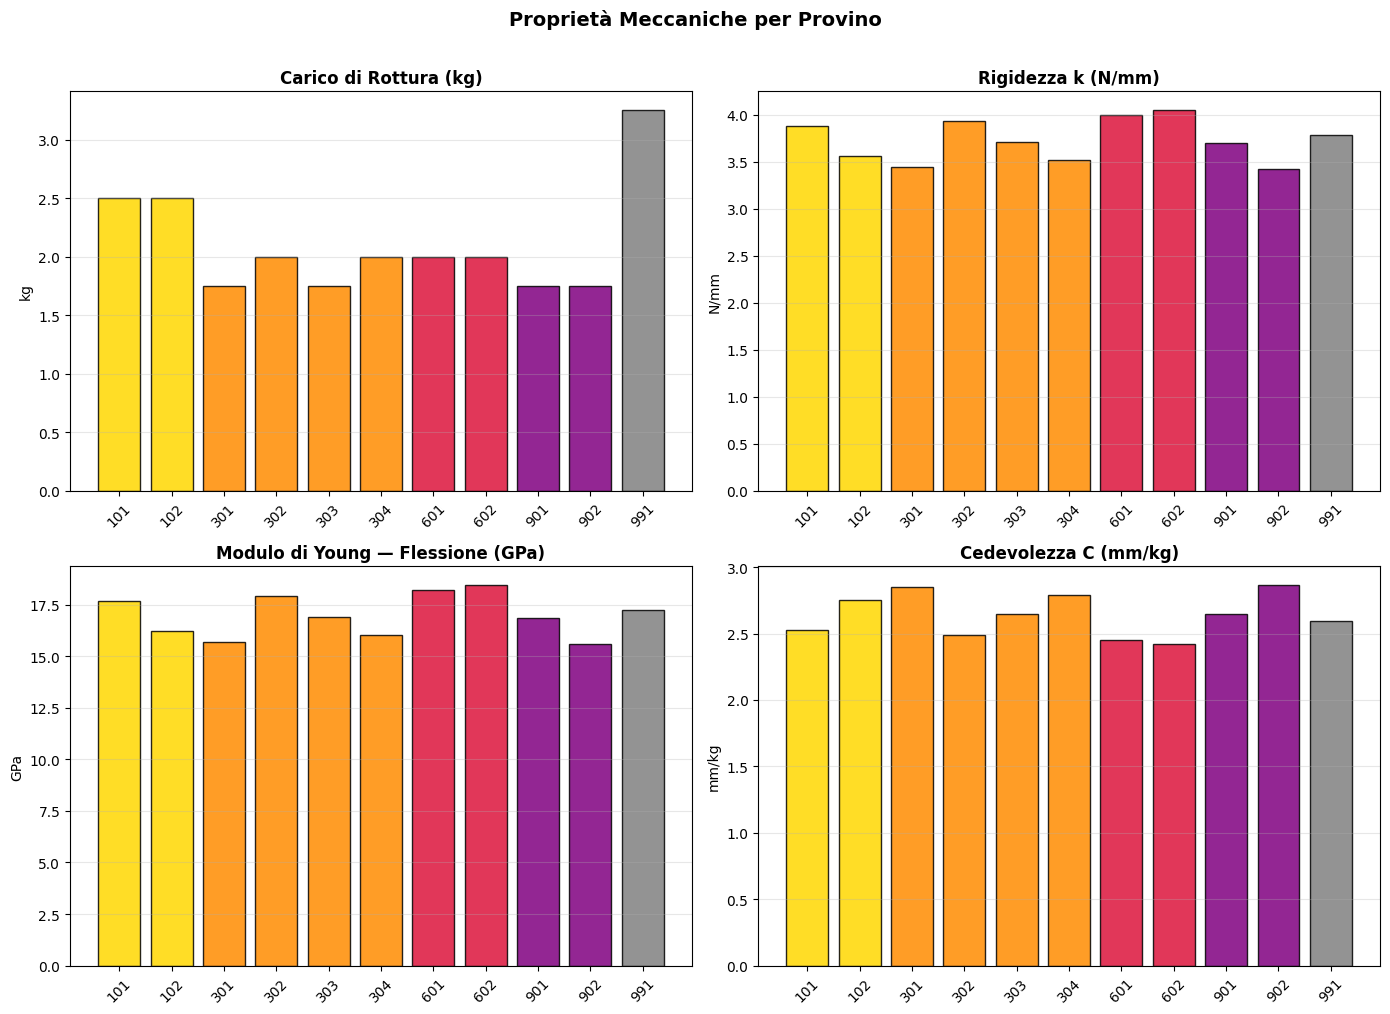

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ordiniamo per stoppage
data = df_mech.sort_values('Provino')
provini = data['Provino'].astype(str)
colors_mech = []
for p in provini:
    prefix = p[:2]
    c, _ = prefix_colors.get(prefix, ('blue', ''))
    colors_mech.append(c)

# 1. Carico di rottura
axes[0, 0].bar(provini, data['Carico Rottura (kg)'], color=colors_mech, edgecolor='black', alpha=0.85)
axes[0, 0].set_title('Carico di Rottura (kg)', fontweight='bold')
axes[0, 0].set_ylabel('kg')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, axis='y', alpha=0.3)

# 2. Rigidezza
axes[0, 1].bar(provini, data['Rigidezza k (N/mm)'], color=colors_mech, edgecolor='black', alpha=0.85)
axes[0, 1].set_title('Rigidezza k (N/mm)', fontweight='bold')
axes[0, 1].set_ylabel('N/mm')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, axis='y', alpha=0.3)

# 3. E flessione
axes[1, 0].bar(provini, data['E_flessione (GPa)'], color=colors_mech, edgecolor='black', alpha=0.85)
axes[1, 0].set_title('Modulo di Young — Flessione (GPa)', fontweight='bold')
axes[1, 0].set_ylabel('GPa')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, axis='y', alpha=0.3)

# 4. Cedevolezza
axes[1, 1].bar(provini, data['Cedevolezza C (mm/kg)'], color=colors_mech, edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Cedevolezza C (mm/kg)', fontweight='bold')
axes[1, 1].set_ylabel('mm/kg')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Proprietà Meccaniche per Provino', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Dataset Unificato

Uniamo in un singolo DataFrame le informazioni termiche (anomalie) e meccaniche per ogni provino.
Questo sarà la base per tutte le analisi successive.

In [11]:
# Rinomina la colonna Provino in provino_id per il merge
df_mech_renamed = df_mech.rename(columns={'Provino': 'provino_id'})

# Merge anomalie + meccanica
df_unified = pd.merge(df_anomaly_summary, df_mech_renamed, on='provino_id', how='inner')

# Aggiungiamo info dalla verifica carichi
df_verif_slim = df_verif[['provino_id', 'max_carico_rilevato_kg', 'stato', 'compliance_mm_kg', 'n_plateau']]
df_unified = pd.merge(df_unified, df_verif_slim, on='provino_id', how='left')

print(f"Dataset unificato: {len(df_unified)} provini x {len(df_unified.columns)} colonne")
print(f"\nColonne disponibili:")
for i, col in enumerate(df_unified.columns):
    print(f"  {i+1:2d}. {col}")

Dataset unificato: 10 provini x 398 colonne

Colonne disponibili:
   1. provino_id
   2. n_passate
   3. mean_anomaly_pv0.01
   4. max_anomaly_pv0.01
   5. total_anomaly_pv0.01
   6. std_anomaly_pv0.01
   7. mean_anomaly_fraction_pv0.01
   8. max_anomaly_fraction_pv0.01
   9. total_anomaly_fraction_pv0.01
  10. std_anomaly_fraction_pv0.01
  11. mean_excess_sum_pv0.01
  12. max_excess_sum_pv0.01
  13. total_excess_sum_pv0.01
  14. std_excess_sum_pv0.01
  15. mean_excess_mean_all_pv0.01
  16. max_excess_mean_all_pv0.01
  17. total_excess_mean_all_pv0.01
  18. std_excess_mean_all_pv0.01
  19. mean_excess_mean_anom_pv0.01
  20. max_excess_mean_anom_pv0.01
  21. total_excess_mean_anom_pv0.01
  22. std_excess_mean_anom_pv0.01
  23. mean_cold_deficit_sum_pv0.01
  24. max_cold_deficit_sum_pv0.01
  25. total_cold_deficit_sum_pv0.01
  26. std_cold_deficit_sum_pv0.01
  27. mean_cold_deficit_mean_all_pv0.01
  28. max_cold_deficit_mean_all_pv0.01
  29. total_cold_deficit_mean_all_pv0.01
  30. std_c

In [12]:
# Mostra le colonne più importanti del dataset unificato
cols_display = [
    'provino_id', 'n_passate', 'Stoppage (s)',
    'mean_anomaly_pv0.05', 'total_anomaly_pv0.05',
    'Carico Rottura (kg)', 'Rigidezza k (N/mm)',
    'E_flessione (GPa)', 'Cedevolezza C (mm/kg)',
    'stato'
]
# Filtra solo le colonne che esistono
cols_display = [c for c in cols_display if c in df_unified.columns]

display(df_unified[cols_display])

,provino_id,n_passate,Stoppage (s),mean_anomaly_pv0.05,total_anomaly_pv0.05,Carico Rottura (kg),Rigidezza k (N/mm),E_flessione (GPa),Cedevolezza C (mm/kg),stato
0,101,200,10,10315.745000,2063149,2.50,3.876828,17.663798,2.529555,PARZIALE
1,102,76,10,1773.381579,134777,2.50,3.565050,16.243258,2.750775,PARZIALE
2,301,75,30,3855.693333,289177,1.75,3.443599,15.689896,2.847791,PARZIALE
3,302,83,30,5396.000000,447868,2.00,3.939532,17.949491,2.489293,PARZIALE
4,303,76,30,4508.802632,342669,1.75,3.708565,16.897149,2.644325,PARZIALE
5,304,76,30,4486.394737,340966,2.00,3.517835,16.028137,2.787694,CORRETTO
6,601,87,60,8144.068966,708534,2.00,3.995237,18.203298,2.454585,PARZIALE
7,602,80,60,8350.037500,668003,2.00,4.048271,18.444937,2.422429,PARZIALE
8,901,82,90,8334.878049,683460,1.75,3.702123,16.867799,2.648926,PARZIALE
9,902,79,90,9733.316456,768932,1.75,3.425033,15.605307,2.863228,PARZIALE


---
## ✅ Dati Pronti

Il dataset unificato `df_unified` contiene per ogni provino:
- **Identità**: `provino_id`, `Stoppage (s)`, `n_passate`
- **Anomalie Termiche**: conteggi (media, max, totale, std) a 8 livelli di p-value
- **Proprietà Meccaniche**: carico di rottura, cedevolezza, rigidezza, E_trazione, E_flessione, R²
- **Verifica**: stato mappatura carichi, max carico rilevato

Nelle celle successive procederemo con l'analisi correlata.

---
## 5. Analisi Focalizzata: Prime 20 Passate (p-value = 0.10)

Dal grafico dell'evoluzione anomalie si osserva che:
- Le **prime 20 passate** contengono il segnale termico più forte e differenziato tra i provini
- Dopo le prime 20 passate il segnale decade e diventa rumoroso
- I provini con **curve più alte** (più anomalie nelle prime passate) tendono ad essere **più fragili**

Focalizziamo l'analisi su:
- **Feature unica:** anomalie nelle prime 20 passate a p-value = 0.10
- **Risposta:** Carico di Rottura (kg)

### 5.1 Estrazione Feature dalle Prime 20 Passate

In [13]:
# Filtriamo solo le prime 20 passate e il p-value 0.10
MAX_STROKES = 20
PV_COL = 'anomaly_pv0.01'

df_early = df_anomaly_counts[df_anomaly_counts['stroke_idx'] < MAX_STROKES].copy()
print(f"Passate filtrate: stroke_idx < {MAX_STROKES}")
print(f"Colonna anomalia: {PV_COL}")
print(f"Righe dopo filtro: {len(df_early)}")

# Per ogni provino: calcola statistiche sulle prime 20 passate
feat_rows = []
for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p].sort_values('stroke_idx')
    vals = sub[PV_COL].values
    
    row = {
        'provino_id': p,
        'n_passate_disponibili': len(vals),
        'mean_anomaly_20': vals.mean(),
        'max_anomaly_20': vals.max(),
        'total_anomaly_20': vals.sum(),
        'median_anomaly_20': np.median(vals),
    }
    feat_rows.append(row)

df_features = pd.DataFrame(feat_rows)

# Merge con le propriet\u00e0 meccaniche
df_mech_r = df_mech.rename(columns={'Provino': 'provino_id'})
df_analysis = pd.merge(df_features, df_mech_r[['provino_id', 'Carico Rottura (kg)', 'Stoppage (s)']], on='provino_id', how='inner')

print(f"\nDataset analisi: {len(df_analysis)} provini")
display(df_analysis)

Passate filtrate: stroke_idx < 20
Colonna anomalia: anomaly_pv0.01
Righe dopo filtro: 220

Dataset analisi: 10 provini


,provino_id,n_passate_disponibili,mean_anomaly_20,max_anomaly_20,total_anomaly_20,median_anomaly_20,Carico Rottura (kg),Stoppage (s)
0,101,20,5109.20,9993,102184,5388.0,2.50,10
1,102,20,3269.30,7259,65386,2988.5,2.50,10
2,301,20,8022.35,13984,160447,8860.0,1.75,30
3,302,20,12955.75,18959,259115,12815.0,2.00,30
4,303,20,11094.40,15605,221888,11702.0,1.75,30
5,304,20,10831.75,15297,216635,11578.5,2.00,30
6,601,20,13519.15,18684,270383,14730.5,2.00,60
7,602,20,20698.90,25784,413978,21310.5,2.00,60
8,901,20,18060.55,24515,361211,18835.0,1.75,90
9,902,20,23658.10,29227,473162,24494.5,1.75,90


### 5.2 Evoluzione Anomalie nelle Prime 20 Passate (p-value = 0.10)
Zoom sulle prime 20 passate dove il segnale è più forte.

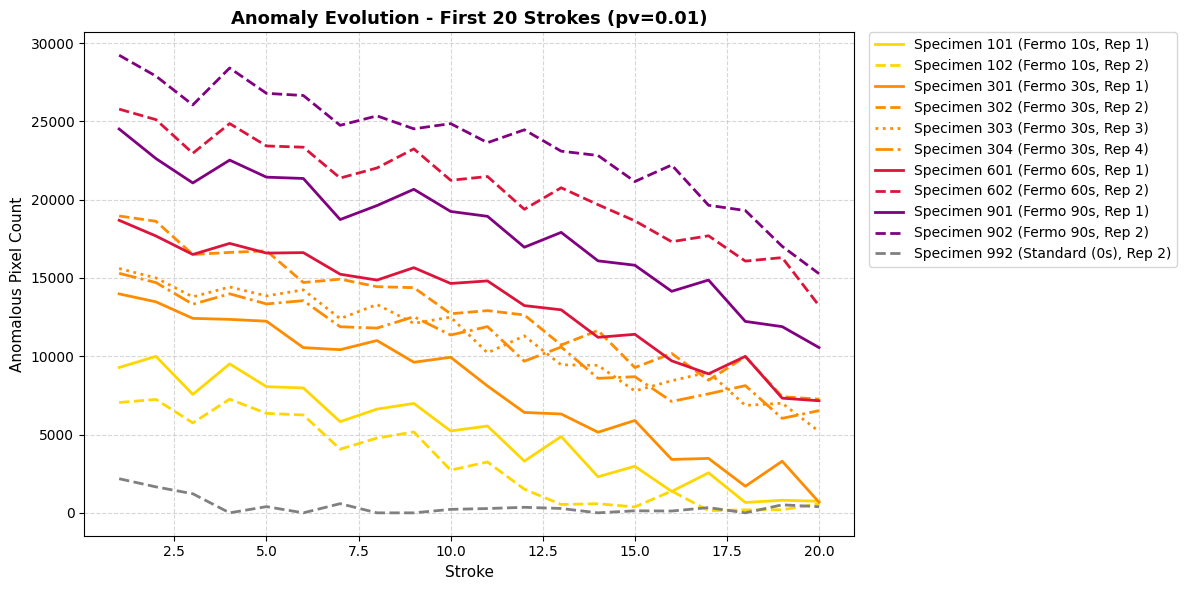

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p].sort_values('stroke_idx')
    prefix = str(p)[:2]
    rep = str(p)[2] if len(str(p)) > 2 else '1'
    color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
    linestyle = style_map.get(rep, '-')

    ax.plot(
        range(1, len(sub) + 1),
        sub[PV_COL].values,
        label=f'Specimen {p} ({desc}, Rep {rep})',
        color=color, linestyle=linestyle, linewidth=2
    )

ax.set_title(f'Anomaly Evolution - First {MAX_STROKES} Strokes (pv=0.01)', fontsize=13, fontweight='bold')
ax.set_xlabel('Stroke', fontsize=11)
ax.set_ylabel('Anomalous Pixel Count', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### 5.3 Correlazione: Anomalie Medie (prime 20 passate) vs Carico di Rottura
Scatter plot con regressione lineare e test di significatività.

CORRELATION: mean_anomaly_20 vs Ultimate Tensile Strength
  Pearson  r = -0.6459,  p-value = 0.0436
  Spearman r = -0.5190,  p-value = 0.1242

POLYNOMIAL REGRESSION (2nd DEGREE)
  y = 3.08e-09 * x² -0.0001 * x +2.7973
  R² = 0.6083


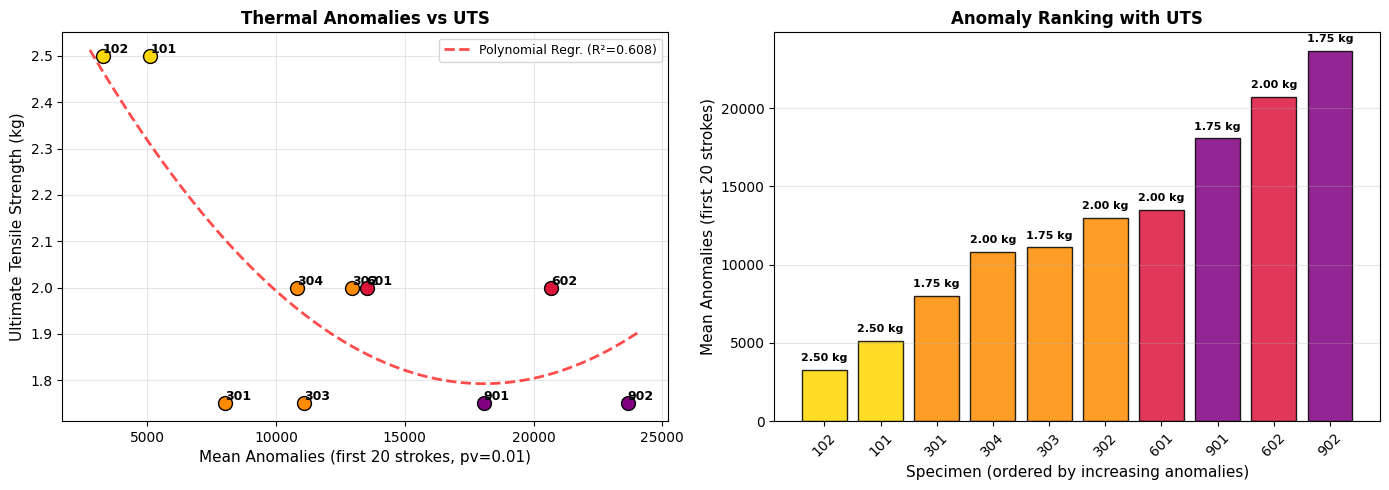

In [15]:
    from scipy.stats import pearsonr, spearmanr
    import matplotlib.pyplot as plt
    import numpy as np

    x = df_analysis['mean_anomaly_20'].values
    y_rot = df_analysis['Carico Rottura (kg)'].values

    # Correlazioni (rimangono uguali, misurano il trend generale)
    r_p, p_p = pearsonr(x, y_rot)
    r_s, p_s = spearmanr(x, y_rot)

    # Regressione polinomiale (2° grado: y = ax^2 + bx + c)
    coeffs = np.polyfit(x, y_rot, 2)
    poly_func = np.poly1d(coeffs)

    # Calcolo manuale dell'R-quadro (R²)
    y_pred = poly_func(x)
    ss_res = np.sum((y_rot - y_pred)**2)
    ss_tot = np.sum((y_rot - np.mean(y_rot))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f"CORRELATION: mean_anomaly_20 vs Ultimate Tensile Strength")
    print(f"{'='*55}")
    print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
    print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
    print(f"")
    print(f"POLYNOMIAL REGRESSION (2nd DEGREE)")
    print(f"{'='*55}")
    # coeffs[0 è a (x^2), coeffs[1] è b (x), coeffs[2] è c (intercetta)
    # Uso la notazione scientifica (.2e) per 'a' perché i quadrati di anomalie grandi danno coefficienti piccolissimi
    print(f"  y = {coeffs[0]:.2e} * x² {coeffs[1]:+.4f} * x {coeffs[2]:+.4f}")
    print(f"  R² = {r_squared:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter con curva polinomiale
    for _, row in df_analysis.iterrows():
        pid = str(row['provino_id'])
        prefix = pid[:2]
        color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
        ax1.scatter(row['mean_anomaly_20'], row['Carico Rottura (kg)'],
                    c=color, s=100, edgecolors='black', zorder=3)
        ax1.annotate(pid, (row['mean_anomaly_20'], row['Carico Rottura (kg)']),
                    fontsize=9, ha='left', va='bottom', fontweight='bold')

    # Disegna la curva di regressione
    x_line = np.linspace(x.min() - 500, x.max() + 500, 100)
    y_line = poly_func(x_line)
    ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
            label=f'Polynomial Regr. (R²={r_squared:.3f})')

    ax1.set_xlabel('Mean Anomalies (first 20 strokes, pv=0.01)', fontsize=11)
    ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
    ax1.set_title('Thermal Anomalies vs UTS', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Bar chart: anomalie medie ordinate, colorate per stoppage
    data_sorted = df_analysis.sort_values('mean_anomaly_20')
    bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

    bars = ax2.bar(data_sorted['provino_id'].astype(str), data_sorted['mean_anomaly_20'],
            color=bar_colors, edgecolor='black', alpha=0.85)

    # Annota il carico di rottura sopra ogni barra
    for bar, (_, row) in zip(bars, data_sorted.iterrows()):
        ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax2.set_xlabel('Specimen (ordered by increasing anomalies)', fontsize=11)
    ax2.set_ylabel('Mean Anomalies (first 20 strokes)', fontsize=11)
    ax2.set_title('Anomaly Ranking with UTS', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

CORRELATION: mean_anomaly_20 vs Ultimate Tensile Strength (Excluding 301, 303)
  Pearson  r = -0.8911,  p-value = 0.0030
  Spearman r = -0.8487,  p-value = 0.0077

POLYNOMIAL REGRESSION (2nd DEGREE)
  y = 2.06e-09 * x² -0.0001 * x +2.8226
  R² = 0.8911


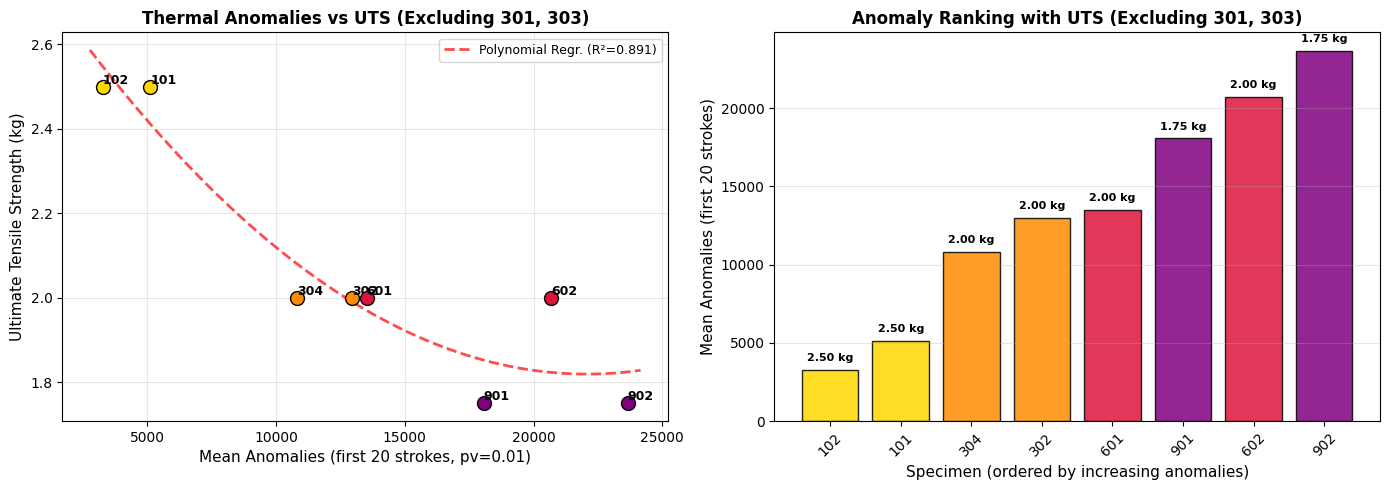

In [16]:
    from scipy.stats import pearsonr, spearmanr
    import numpy as np
    import matplotlib.pyplot as plt

    # ==========================================
    # FILTER: Remove specimens 301 and 303
    # ==========================================
    provini_da_escludere = ['301', '303']
    df_filtered = df_analysis[~df_analysis['provino_id'].astype(str).isin(provini_da_escludere)].copy()

    # Usiamo il dataframe filtrato per i valori x e y
    x = df_filtered['mean_anomaly_20'].values
    y_rot = df_filtered['Carico Rottura (kg)'].values

    # Correlazioni
    r_p, p_p = pearsonr(x, y_rot)
    r_s, p_s = spearmanr(x, y_rot)

    # Regressione polinomiale (2° grado: y = ax^2 + bx + c)
    coeffs = np.polyfit(x, y_rot, 2)
    poly_func = np.poly1d(coeffs)

    # Calcolo manuale dell'R-quadro (R²)
    y_pred = poly_func(x)
    ss_res = np.sum((y_rot - y_pred)**2)
    ss_tot = np.sum((y_rot - np.mean(y_rot))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print(f"CORRELATION: mean_anomaly_20 vs Ultimate Tensile Strength (Excluding 301, 303)")
    print(f"{'='*65}")
    print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
    print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
    print(f"")
    print(f"POLYNOMIAL REGRESSION (2nd DEGREE)")
    print(f"{'='*65}")
    print(f"  y = {coeffs[0]:.2e} * x² {coeffs[1]:+.4f} * x {coeffs[2]:+.4f}")
    print(f"  R² = {r_squared:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter con curva polinomiale
    for _, row in df_filtered.iterrows():
        pid = str(row['provino_id'])
        prefix = pid[:2]
        color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
        ax1.scatter(row['mean_anomaly_20'], row['Carico Rottura (kg)'],
                    c=color, s=100, edgecolors='black', zorder=3)
        ax1.annotate(pid, (row['mean_anomaly_20'], row['Carico Rottura (kg)']),
                    fontsize=9, ha='left', va='bottom', fontweight='bold')

    # Disegna la curva di regressione
    x_line = np.linspace(x.min() - 500, x.max() + 500, 100)
    y_line = poly_func(x_line)
    ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
            label=f'Polynomial Regr. (R²={r_squared:.3f})')

    ax1.set_xlabel('Mean Anomalies (first 20 strokes, pv=0.01)', fontsize=11)
    ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
    ax1.set_title('Thermal Anomalies vs UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Bar chart: anomalie medie ordinate, colorate per stoppage
    data_sorted = df_filtered.sort_values('mean_anomaly_20')
    bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

    bars = ax2.bar(data_sorted['provino_id'].astype(str), data_sorted['mean_anomaly_20'],
            color=bar_colors, edgecolor='black', alpha=0.85)

    # Annota il carico di rottura sopra ogni barra
    for bar, (_, row) in zip(bars, data_sorted.iterrows()):
        ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax2.set_xlabel('Specimen (ordered by increasing anomalies)', fontsize=11)
    ax2.set_ylabel('Mean Anomalies (first 20 strokes)', fontsize=11)
    ax2.set_title('Anomaly Ranking with UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength
  Pearson  r = -0.6632,  p-value = 0.0366
  Spearman r = -0.4671,  p-value = 0.1735

LINEAR REGRESSION
  y = -3.317603e-06 * x + 2.2925
  R² = 0.4398
  p-value = 0.0366
  Standard Error (slope) = 1.323690e-06
  Significance: **


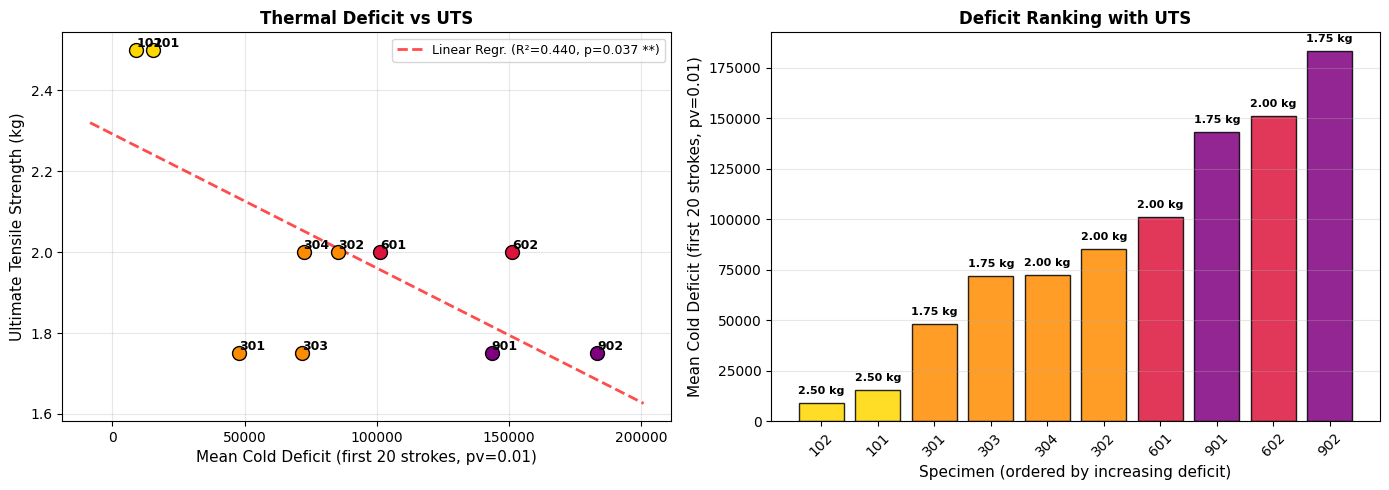

In [17]:
from scipy.stats import pearsonr, spearmanr, linregress
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1. FEATURE CALCULATION (COLD DEFICIT)
# =========================================================
MAX_STROKES = 20
DEFICIT_COL = 'cold_deficit_sum_pv0.01'

df_early = df_anomaly_counts[df_anomaly_counts['stroke_idx'] < MAX_STROKES]
feat_rows = []
for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p]
    vals = sub[DEFICIT_COL].values
    feat_rows.append({
        'provino_id': str(p),
        'mean_deficit_20': vals.mean()
    })
df_features_def = pd.DataFrame(feat_rows)

# Merge con le proprietà meccaniche
df_mech_r = df_mech.rename(columns={'Provino': 'provino_id'})
df_mech_r['provino_id'] = df_mech_r['provino_id'].astype(str)
df_analysis_def = pd.merge(df_features_def, df_mech_r[['provino_id', 'Carico Rottura (kg)', 'Stoppage (s)']], on='provino_id',
how='inner')

# =========================================================
# 2. LINEAR REGRESSION (ALL POINTS)
# =========================================================
# Nessun filtro, utilizziamo tutto il dataframe
x = df_analysis_def['mean_deficit_20'].values
y_rot = df_analysis_def['Carico Rottura (kg)'].values

# Correlazioni
r_p, p_p = pearsonr(x, y_rot)
r_s, p_s = spearmanr(x, y_rot)

# Regressione lineare classica (linregress)
slope, intercept, r_value, p_value, std_err = linregress(x, y_rot)

print(f"CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength")
print(f"{'='*68}")
print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
print(f"")
print(f"LINEAR REGRESSION")
print(f"{'='*68}")
print(f"  y = {slope:+.6e} * x + {intercept:.4f}")
print(f"  R² = {r_value**2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  Standard Error (slope) = {std_err:.6e}")

sig = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else 'ns'
print(f"  Significance: {sig}")

# =========================================================
# 3. PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con linea di regressione
for _, row in df_analysis_def.iterrows():
    pid = str(row['provino_id'])
    prefix = pid[:2]
    color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
    ax1.scatter(row['mean_deficit_20'], row['Carico Rottura (kg)'],
                c=color, s=100, edgecolors='black', zorder=3)
    ax1.annotate(pid, (row['mean_deficit_20'], row['Carico Rottura (kg)']),
                fontsize=9, ha='left', va='bottom', fontweight='bold')

# Disegna la retta di regressione (margine 10% per i bordi)
margin = (x.max() - x.min()) * 0.1
x_line = np.linspace(x.min() - margin, x.max() + margin, 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
        label=f'Linear Regr. (R²={r_value**2:.3f}, p={p_value:.3f} {sig})')

ax1.set_xlabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
ax1.set_title('Thermal Deficit vs UTS', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bar chart
data_sorted = df_analysis_def.sort_values('mean_deficit_20')
bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

bars = ax2.bar(data_sorted['provino_id'], data_sorted['mean_deficit_20'],
        color=bar_colors, edgecolor='black', alpha=0.85)

for bar, (_, row) in zip(bars, data_sorted.iterrows()):
    ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('Specimen (ordered by increasing deficit)', fontsize=11)
ax2.set_ylabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax2.set_title('Deficit Ranking with UTS', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength (Excluding 301, 303)
  Pearson  r = -0.9129,  p-value = 0.0015
  Spearman r = -0.8487,  p-value = 0.0077

LINEAR REGRESSION
  y = -4.226907e-06 * x + 2.4650
  R² = 0.8334
  p-value = 0.0015
  Standard Error (slope) = 7.714331e-07
  Significance: ***


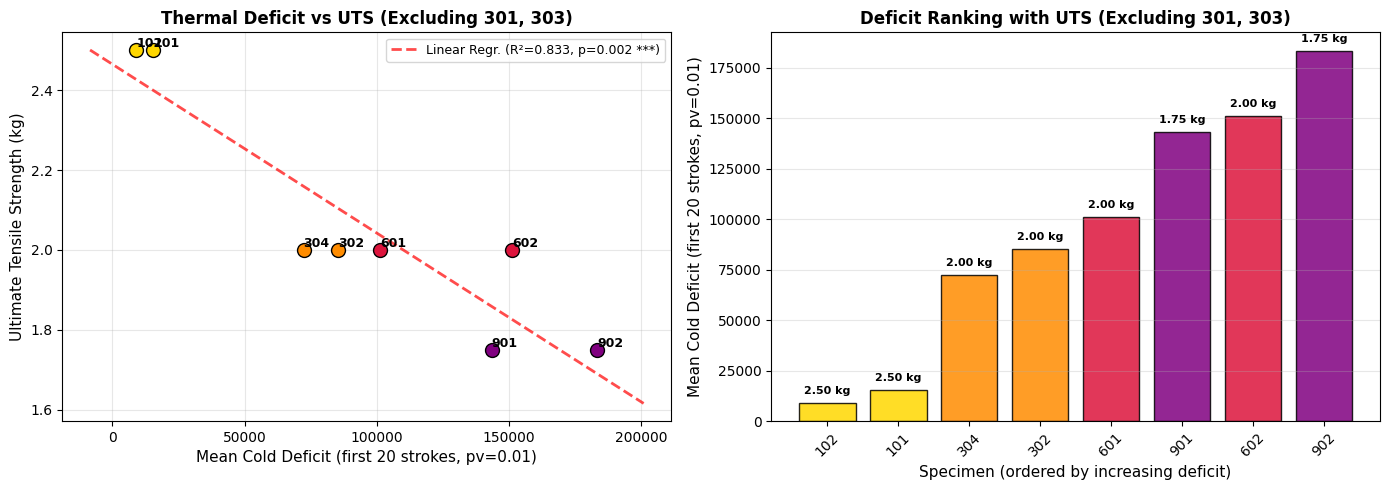

In [18]:
from scipy.stats import pearsonr, spearmanr, linregress
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1. FEATURE CALCULATION (COLD DEFICIT)
# =========================================================
MAX_STROKES = 20
DEFICIT_COL = 'cold_deficit_sum_pv0.01'

df_early = df_anomaly_counts[df_anomaly_counts['stroke_idx'] < MAX_STROKES]
feat_rows = []
for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p]
    vals = sub[DEFICIT_COL].values
    feat_rows.append({
        'provino_id': str(p),
        'mean_deficit_20': vals.mean()
    })
df_features_def = pd.DataFrame(feat_rows)

# Merge con le proprietà meccaniche
df_mech_r = df_mech.rename(columns={'Provino': 'provino_id'})
df_mech_r['provino_id'] = df_mech_r['provino_id'].astype(str)
df_analysis_def = pd.merge(df_features_def, df_mech_r[['provino_id', 'Carico Rottura (kg)', 'Stoppage (s)']], on='provino_id',
how='inner')

# =========================================================
# 2. FILTERING PROVINOS 301 AND 303 & LINEAR REGRESSION
# =========================================================
provini_da_escludere = ['301', '303']
df_filtered = df_analysis_def[~df_analysis_def['provino_id'].isin(provini_da_escludere)].copy()

x = df_filtered['mean_deficit_20'].values
y_rot = df_filtered['Carico Rottura (kg)'].values

# Correlazioni
r_p, p_p = pearsonr(x, y_rot)
r_s, p_s = spearmanr(x, y_rot)

# Regressione lineare classica (linregress)
slope, intercept, r_value, p_value, std_err = linregress(x, y_rot)

print(f"CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength (Excluding 301, 303)")
print(f"{'='*68}")
print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
print(f"")
print(f"LINEAR REGRESSION")
print(f"{'='*68}")
print(f"  y = {slope:+.6e} * x + {intercept:.4f}")
print(f"  R² = {r_value**2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  Standard Error (slope) = {std_err:.6e}")

sig = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else 'ns'
print(f"  Significance: {sig}")

# =========================================================
# 3. PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con linea di regressione
for _, row in df_filtered.iterrows():
    pid = str(row['provino_id'])
    prefix = pid[:2]
    color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
    ax1.scatter(row['mean_deficit_20'], row['Carico Rottura (kg)'],
                c=color, s=100, edgecolors='black', zorder=3)
    ax1.annotate(pid, (row['mean_deficit_20'], row['Carico Rottura (kg)']),
                fontsize=9, ha='left', va='bottom', fontweight='bold')

# Disegna la retta di regressione (margine 10% per i bordi)
margin = (x.max() - x.min()) * 0.1
x_line = np.linspace(x.min() - margin, x.max() + margin, 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
        label=f'Linear Regr. (R²={r_value**2:.3f}, p={p_value:.3f} {sig})')

ax1.set_xlabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
ax1.set_title('Thermal Deficit vs UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bar chart
data_sorted = df_filtered.sort_values('mean_deficit_20')
bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

bars = ax2.bar(data_sorted['provino_id'], data_sorted['mean_deficit_20'],
        color=bar_colors, edgecolor='black', alpha=0.85)

for bar, (_, row) in zip(bars, data_sorted.iterrows()):
    ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('Specimen (ordered by increasing deficit)', fontsize=11)
ax2.set_ylabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax2.set_title('Deficit Ranking with UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength
  Pearson  r = -0.6632,  p-value = 0.0366
  Spearman r = -0.4671,  p-value = 0.1735

POLYNOMIAL REGRESSION (2nd DEGREE)
  y = 4.03e-11 * x² -0.0000 * x +2.5247
  R² = 0.6216


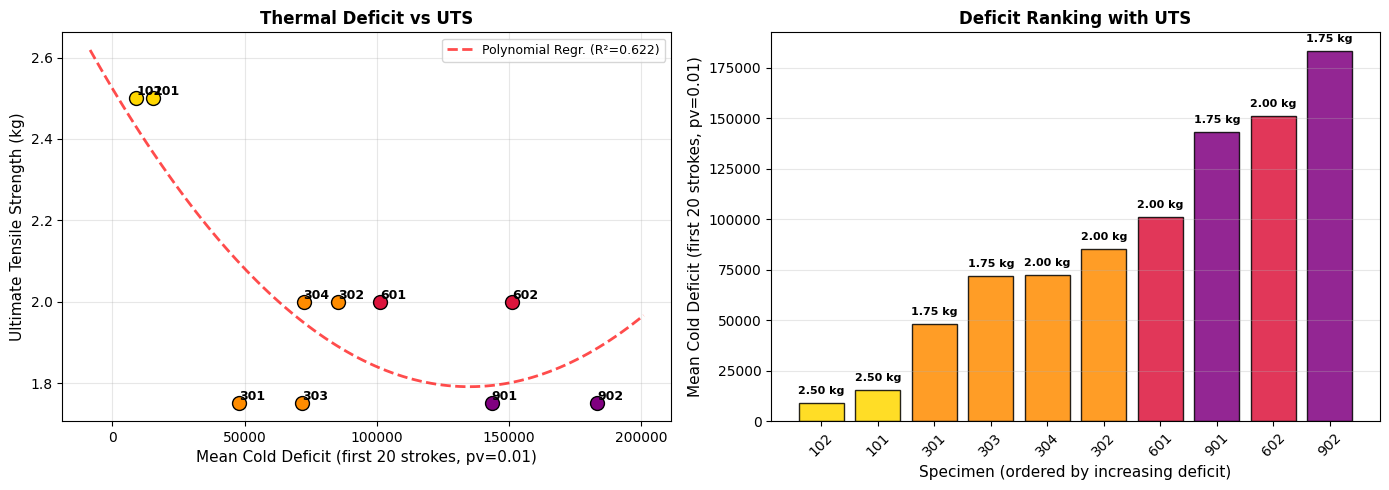

In [19]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1. FEATURE CALCULATION (COLD DEFICIT)
# =========================================================
MAX_STROKES = 20
DEFICIT_COL = 'cold_deficit_sum_pv0.01'

df_early = df_anomaly_counts[df_anomaly_counts['stroke_idx'] < MAX_STROKES]
feat_rows = []
for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p]
    vals = sub[DEFICIT_COL].values
    feat_rows.append({
        'provino_id': str(p),
        'mean_deficit_20': vals.mean()
    })
df_features_def = pd.DataFrame(feat_rows)

# Merge con le proprietà meccaniche
df_mech_r = df_mech.rename(columns={'Provino': 'provino_id'})
df_mech_r['provino_id'] = df_mech_r['provino_id'].astype(str)
df_analysis_def = pd.merge(df_features_def, df_mech_r[['provino_id', 'Carico Rottura (kg)', 'Stoppage (s)']], on='provino_id',
how='inner')

# =========================================================
# 2. POLYNOMIAL REGRESSION (ALL POINTS)
# =========================================================
# Nessun filtro, usiamo direttamente df_analysis_def
x = df_analysis_def['mean_deficit_20'].values
y_rot = df_analysis_def['Carico Rottura (kg)'].values

# Correlazioni
r_p, p_p = pearsonr(x, y_rot)
r_s, p_s = spearmanr(x, y_rot)

# Regressione polinomiale di 2° grado (y = ax^2 + bx + c)
coeffs = np.polyfit(x, y_rot, 2)
poly_func = np.poly1d(coeffs)

# Calcolo manuale R²
y_pred = poly_func(x)
ss_res = np.sum((y_rot - y_pred)**2)
ss_tot = np.sum((y_rot - np.mean(y_rot))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength")
print(f"{'='*68}")
print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
print(f"")
print(f"POLYNOMIAL REGRESSION (2nd DEGREE)")
print(f"{'='*68}")
print(f"  y = {coeffs[0]:.2e} * x² {coeffs[1]:+.4f} * x {coeffs[2]:+.4f}")
print(f"  R² = {r_squared:.4f}")

# =========================================================
# 3. PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con curva
for _, row in df_analysis_def.iterrows():
    pid = str(row['provino_id'])
    prefix = pid[:2]
    color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
    ax1.scatter(row['mean_deficit_20'], row['Carico Rottura (kg)'],
                c=color, s=100, edgecolors='black', zorder=3)
    ax1.annotate(pid, (row['mean_deficit_20'], row['Carico Rottura (kg)']),
                fontsize=9, ha='left', va='bottom', fontweight='bold')

# Disegna la curva di regressione (margine 10% per i bordi)
margin = (x.max() - x.min()) * 0.1
x_line = np.linspace(x.min() - margin, x.max() + margin, 100)
y_line = poly_func(x_line)
ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
        label=f'Polynomial Regr. (R²={r_squared:.3f})')

ax1.set_xlabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
ax1.set_title('Thermal Deficit vs UTS', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bar chart
data_sorted = df_analysis_def.sort_values('mean_deficit_20')
bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

bars = ax2.bar(data_sorted['provino_id'], data_sorted['mean_deficit_20'],
        color=bar_colors, edgecolor='black', alpha=0.85)

for bar, (_, row) in zip(bars, data_sorted.iterrows()):
    ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('Specimen (ordered by increasing deficit)', fontsize=11)
ax2.set_ylabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax2.set_title('Deficit Ranking with UTS', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength (Excluding 301, 303)
  Pearson  r = -0.9129,  p-value = 0.0015
  Spearman r = -0.8487,  p-value = 0.0077

POLYNOMIAL REGRESSION (2nd DEGREE)
  y = 2.48e-11 * x² -0.0000 * x +2.5884
  R² = 0.9111


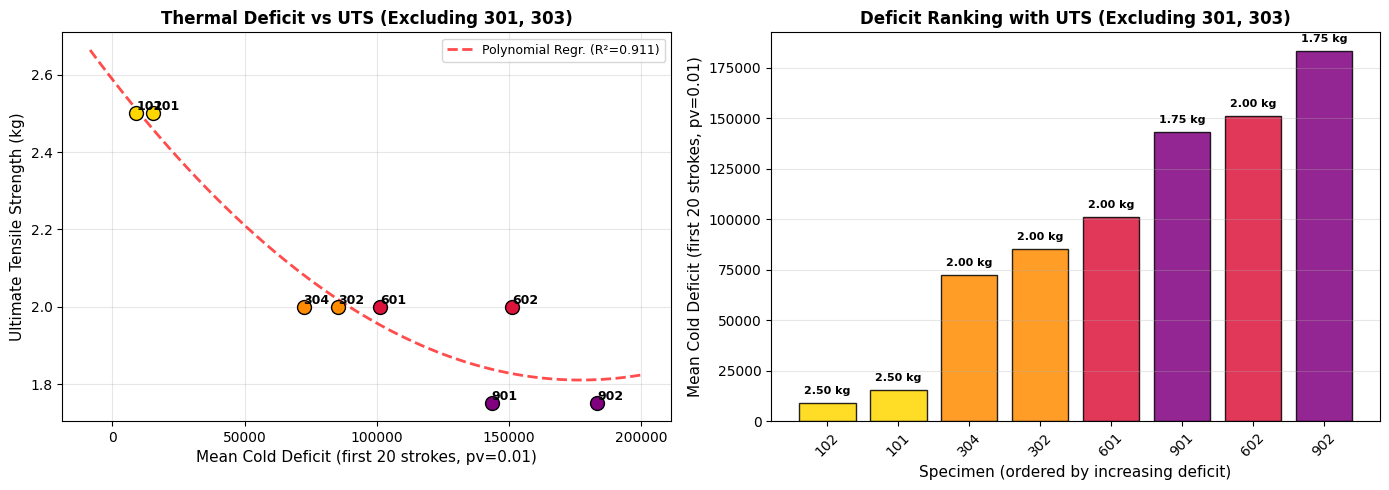

In [20]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================================================
# 1. FEATURE CALCULATION (COLD DEFICIT)
# =========================================================
MAX_STROKES = 20
DEFICIT_COL = 'cold_deficit_sum_pv0.01'

df_early = df_anomaly_counts[df_anomaly_counts['stroke_idx'] < MAX_STROKES]
feat_rows = []
for p in sorted(df_early['provino_id'].unique()):
    sub = df_early[df_early['provino_id'] == p]
    vals = sub[DEFICIT_COL].values
    feat_rows.append({
        'provino_id': str(p),
        'mean_deficit_20': vals.mean()
    })
df_features_def = pd.DataFrame(feat_rows)

# Merge con le proprietà meccaniche
df_mech_r = df_mech.rename(columns={'Provino': 'provino_id'})
df_mech_r['provino_id'] = df_mech_r['provino_id'].astype(str)
df_analysis_def = pd.merge(df_features_def, df_mech_r[['provino_id', 'Carico Rottura (kg)', 'Stoppage (s)']], on='provino_id',
how='inner')

# =========================================================
# 2. FILTERING PROVINOS 301 AND 303 & REGRESSION
# =========================================================
provini_da_escludere = ['301', '303']
df_filtered = df_analysis_def[~df_analysis_def['provino_id'].isin(provini_da_escludere)].copy()

x = df_filtered['mean_deficit_20'].values
y_rot = df_filtered['Carico Rottura (kg)'].values

# Correlazioni
r_p, p_p = pearsonr(x, y_rot)
r_s, p_s = spearmanr(x, y_rot)

# Regressione polinomiale di 2° grado (y = ax^2 + bx + c)
coeffs = np.polyfit(x, y_rot, 2)
poly_func = np.poly1d(coeffs)

# Calcolo manuale R²
y_pred = poly_func(x)
ss_res = np.sum((y_rot - y_pred)**2)
ss_tot = np.sum((y_rot - np.mean(y_rot))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"CORRELATION: Mean Cold Deficit vs Ultimate Tensile Strength (Excluding 301, 303)")
print(f"{'='*68}")
print(f"  Pearson  r = {r_p:+.4f},  p-value = {p_p:.4f}")
print(f"  Spearman r = {r_s:+.4f},  p-value = {p_s:.4f}")
print(f"")
print(f"POLYNOMIAL REGRESSION (2nd DEGREE)")
print(f"{'='*68}")
print(f"  y = {coeffs[0]:.2e} * x² {coeffs[1]:+.4f} * x {coeffs[2]:+.4f}")
print(f"  R² = {r_squared:.4f}")

# =========================================================
# 3. PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con curva
for _, row in df_filtered.iterrows():
    pid = str(row['provino_id'])
    prefix = pid[:2]
    color, desc = prefix_colors.get(prefix, ('blue', 'Unknown'))
    ax1.scatter(row['mean_deficit_20'], row['Carico Rottura (kg)'],
                c=color, s=100, edgecolors='black', zorder=3)
    ax1.annotate(pid, (row['mean_deficit_20'], row['Carico Rottura (kg)']),
                fontsize=9, ha='left', va='bottom', fontweight='bold')

# Disegna la curva di regressione (margine 10% per i bordi)
margin = (x.max() - x.min()) * 0.1
x_line = np.linspace(x.min() - margin, x.max() + margin, 100)
y_line = poly_func(x_line)
ax1.plot(x_line, y_line, 'r--', alpha=0.7, linewidth=2,
        label=f'Polynomial Regr. (R²={r_squared:.3f})')

ax1.set_xlabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax1.set_ylabel('Ultimate Tensile Strength (kg)', fontsize=11)
ax1.set_title('Thermal Deficit vs UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bar chart
data_sorted = df_filtered.sort_values('mean_deficit_20')
bar_colors = [prefix_colors.get(str(p)[:2], ('blue', ''))[0] for p in data_sorted['provino_id']]

bars = ax2.bar(data_sorted['provino_id'], data_sorted['mean_deficit_20'],
        color=bar_colors, edgecolor='black', alpha=0.85)

for bar, (_, row) in zip(bars, data_sorted.iterrows()):
    ax2.annotate(f"{row['Carico Rottura (kg)']:.2f} kg",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xlabel('Specimen (ordered by increasing deficit)', fontsize=11)
ax2.set_ylabel('Mean Cold Deficit (first 20 strokes, pv=0.01)', fontsize=11)
ax2.set_title('Deficit Ranking with UTS (Excluding 301, 303)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

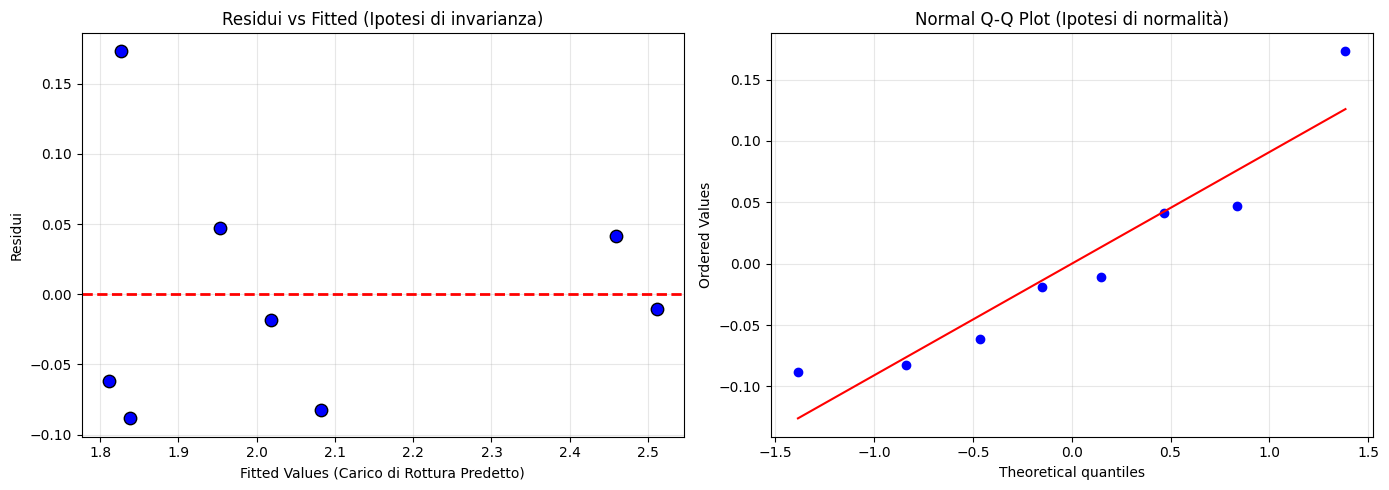

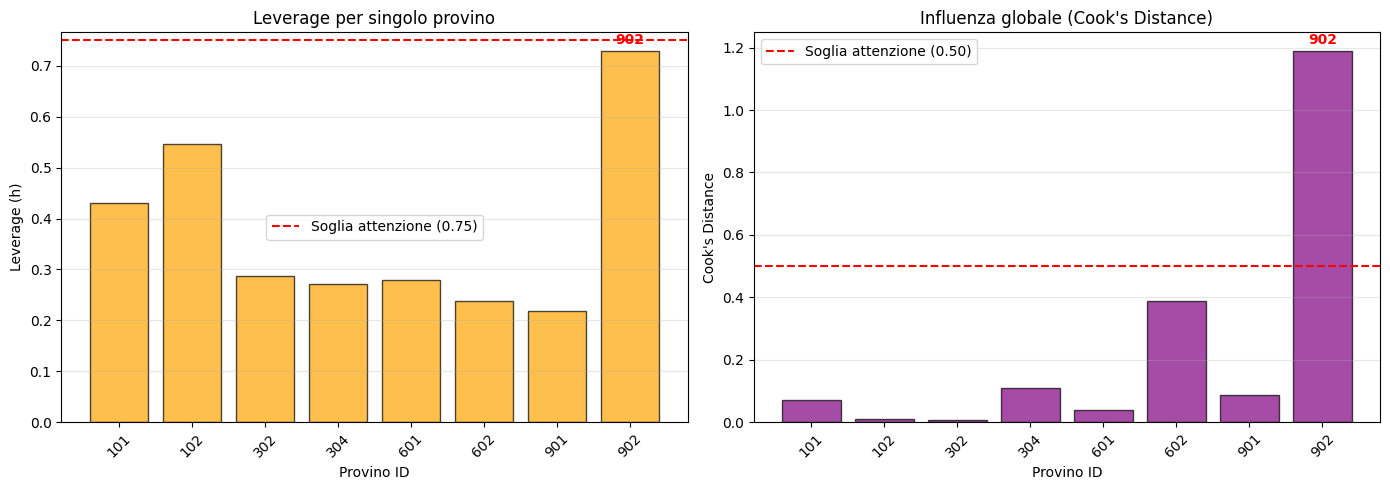

STATISTICAL SUMMARY & DIAGNOSTICS
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     25.61
Date:                Fri, 10 Jul 2026   Prob (F-statistic):            0.00236
Time:                        17:36:34   Log-Likelihood:                 8.7307
No. Observations:                   8   AIC:                            -11.46
Df Residuals:                       5   BIC:                            -11.22
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import numpy as np

# =========================================================
# 4. RESIDUAL ANALYSIS & LEVERAGE (DIAGNOSTICS)
# =========================================================

# Build the design matrix for the 2nd degree polynomial regression
# Model: y = beta0 + beta1*x + beta2*x^2
X_design = np.column_stack((x, x**2))
X_design = sm.add_constant(X_design)  # Adds the intercept (column of 1s)

# Fit the model using statsmodels to access diagnostic metrics
ols_model = sm.OLS(y_rot, X_design).fit()

# Extract residuals, fitted values, and influence metrics
residuals = ols_model.resid
fitted = ols_model.fittedvalues

influence = ols_model.get_influence()
leverage = influence.hat_matrix_diag
cooks_d, p_vals = influence.cooks_distance
std_residuals = influence.resid_studentized_internal

# ---------------------------------------------------------
# PLOT 1: Residuals and Normality (Top Row)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot: Residuals vs Fitted values (Homoscedasticity)
axs[0].scatter(fitted, residuals, facecolors='none', edgecolors='blue', s=60)
axs[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axs[0].set_xlabel('Fitted values')
axs[0].set_ylabel('Residuals')
axs[0].set_title('Residuals vs Fitted')
axs[0].grid(True, alpha=0.3)

# 2. Q-Q plot: Normality of residuals
stats.probplot(std_residuals, dist="norm", plot=axs[1])
# R-style open circles styling for Q-Q plot
axs[1].get_lines()[0].set_markerfacecolor('none')
axs[1].get_lines()[0].set_markeredgecolor('blue')
axs[1].set_title('Normal Q-Q')
axs[1].set_xlabel('Theoretical Quantiles')
axs[1].set_ylabel('Standardized Residuals')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 2: R-Style Influence Diagnostics (Bottom Row)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
provini = df_filtered['provino_id'].values

# 3. Scale-Location (Spread-Location) Plot
sqrt_abs_std_resid = np.sqrt(np.abs(std_residuals))
axs[0].scatter(fitted, sqrt_abs_std_resid, facecolors='none', edgecolors='blue', s=60)
axs[0].set_xlabel('Fitted values')
axs[0].set_ylabel(r'$\sqrt{|\text{Standardized Residuals}|}$')
axs[0].set_title('Scale-Location')
axs[0].grid(True, alpha=0.3)

# 4. Residuals vs Leverage Plot
axs[1].scatter(leverage, std_residuals, facecolors='none', edgecolors='blue', s=60)
axs[1].axhline(0, color='red', linestyle='--', linewidth=1.5)

# Highlight top 3 extreme points by Cook's distance (classic R behavior)
top_3_idx = np.argsort(cooks_d)[-3:]
for i in top_3_idx:
    axs[1].annotate(provini[i],
                    (leverage[i], std_residuals[i]),
                    xytext=(5, 5), textcoords='offset points',
                    color='red', fontsize=9, fontweight='bold')

# Plot High Leverage Threshold
p_params = X_design.shape[1]
n_obs = len(x)
lev_threshold = 2 * p_params / n_obs
axs[1].axvline(lev_threshold, color='red', linestyle=':', alpha=0.6, label=f'High Leverage ({lev_threshold:.2f})')

axs[1].set_xlabel('Leverage')
axs[1].set_ylabel('Standardized Residuals')
axs[1].set_title('Residuals vs Leverage')
axs[1].legend(loc='lower right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 5. PRINT SUMMARY
# =========================================================
print("="*68)
print("STATISTICAL SUMMARY & DIAGNOSTICS")
print("="*68)
print(ols_model.summary())


### 5.4 Confronto per Gruppo di Stoppage
Anomalie medie (prime 20 passate) vs carico di rottura, raggruppati per tempo di fermo.

STATISTICHE PER GRUPPO DI STOPPAGE
  Stoppage |   N |    Anomalie Medie 20 |  Carico Rottura (kg)
-----------+-----+----------------------+---------------------
       10s |   2 |        4189 +/- 1301 |        2.50 +/- 0.00
       30s |   4 |       10726 +/- 2035 |        1.88 +/- 0.14
       60s |   2 |       17109 +/- 5077 |        2.00 +/- 0.00
       90s |   2 |       20859 +/- 3958 |        1.75 +/- 0.00


C:\Users\simon\AppData\Local\Temp\ipykernel_16828\439159722.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([groups_anom[s] for s in stoppage_order],
C:\Users\simon\AppData\Local\Temp\ipykernel_16828\439159722.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([groups_break[s] for s in stoppage_order],


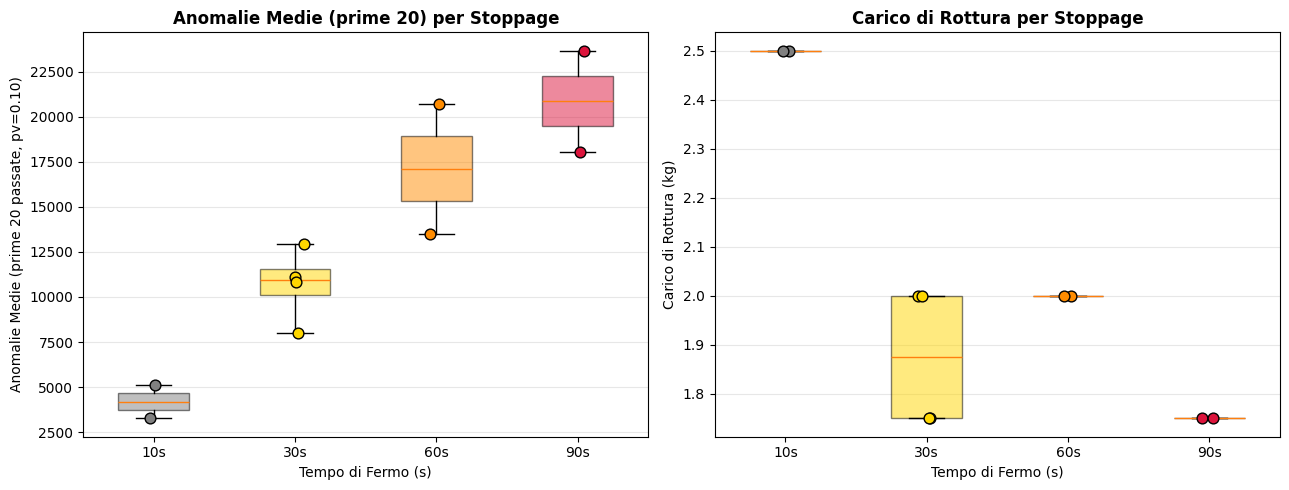


TEST ANOVA
  Stoppage -> Anomalie (prime 20): F=11.968, p=0.0061 ***
  Stoppage -> Carico Rottura:      F=22.000, p=0.0012 ***


In [21]:
from scipy.stats import f_oneway, kruskal

# Statistiche per gruppo
print(f"STATISTICHE PER GRUPPO DI STOPPAGE")
print(f"{'='*80}")
print(f"{'Stoppage':>10s} | {'N':>3s} | {'Anomalie Medie 20':>20s} | {'Carico Rottura (kg)':>20s}")
print(f"{'-'*10}-+-{'-'*3}-+-{'-'*20}-+-{'-'*20}")

groups_anom = {}
groups_break = {}

for s in sorted(df_analysis['Stoppage (s)'].unique()):
    sub = df_analysis[df_analysis['Stoppage (s)'] == s]
    s_int = int(s)
    groups_anom[s_int] = sub['mean_anomaly_20'].values.tolist()
    groups_break[s_int] = sub['Carico Rottura (kg)'].values.tolist()
    
    anom_str = f"{sub['mean_anomaly_20'].mean():.0f} +/- {sub['mean_anomaly_20'].std():.0f}"
    rot_str = f"{sub['Carico Rottura (kg)'].mean():.2f} +/- {sub['Carico Rottura (kg)'].std():.2f}"
    print(f"{s_int:>9d}s | {len(sub):>3d} | {anom_str:>20s} | {rot_str:>20s}")

# Box plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

stoppage_order = sorted(groups_anom.keys())
box_colors = ['gray', 'gold', 'darkorange', 'crimson', 'purple']

# Anomalie per gruppo
bp1 = ax1.boxplot([groups_anom[s] for s in stoppage_order], 
                   labels=[f'{s}s' for s in stoppage_order],
                   patch_artist=True, widths=0.5)
for patch, color in zip(bp1['boxes'], box_colors[:len(stoppage_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
for i, s in enumerate(stoppage_order):
    x_jitter = np.random.normal(i+1, 0.04, len(groups_anom[s]))
    ax1.scatter(x_jitter, groups_anom[s], c=box_colors[i], edgecolors='black', s=60, zorder=3)

ax1.set_title('Anomalie Medie (prime 20) per Stoppage', fontweight='bold')
ax1.set_xlabel('Tempo di Fermo (s)')
ax1.set_ylabel('Anomalie Medie (prime 20 passate, pv=0.10)')
ax1.grid(True, axis='y', alpha=0.3)

# Rottura per gruppo
bp2 = ax2.boxplot([groups_break[s] for s in stoppage_order],
                   labels=[f'{s}s' for s in stoppage_order],
                   patch_artist=True, widths=0.5)
for patch, color in zip(bp2['boxes'], box_colors[:len(stoppage_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
for i, s in enumerate(stoppage_order):
    x_jitter = np.random.normal(i+1, 0.04, len(groups_break[s]))
    ax2.scatter(x_jitter, groups_break[s], c=box_colors[i], edgecolors='black', s=60, zorder=3)

ax2.set_title('Carico di Rottura per Stoppage', fontweight='bold')
ax2.set_xlabel('Tempo di Fermo (s)')
ax2.set_ylabel('Carico di Rottura (kg)')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ANOVA
print(f"\nTEST ANOVA")
print(f"{'='*55}")
valid_anom = [v for v in groups_anom.values() if len(v) >= 2]
valid_break = [v for v in groups_break.values() if len(v) >= 2]

if len(valid_anom) >= 2:
    F, p = f_oneway(*valid_anom)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'ns'
    print(f"  Stoppage -> Anomalie (prime 20): F={F:.3f}, p={p:.4f} {sig}")

if len(valid_break) >= 2:
    F, p = f_oneway(*valid_break)
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'ns'
    print(f"  Stoppage -> Carico Rottura:      F={F:.3f}, p={p:.4f} {sig}")

### 5.5 Conclusioni

In [22]:
print("=" * 70)
print("CONCLUSIONI: Anomalie Termiche (prime 20 passate) vs Carico di Rottura")
print("=" * 70)

print(f"\n1. DATASET")
print(f"   Provini analizzati: {len(df_analysis)}")
print(f"   Feature: anomalie medie nelle prime {MAX_STROKES} passate (p-value=0.10)")
print(f"   Risposta: Carico di Rottura (kg)")
print(f"   Range anomalie: {df_analysis['mean_anomaly_20'].min():.0f} - {df_analysis['mean_anomaly_20'].max():.0f}")
print(f"   Range rottura:  {df_analysis['Carico Rottura (kg)'].min():.2f} - {df_analysis['Carico Rottura (kg)'].max():.2f} kg")

print(f"\n2. CORRELAZIONE")
print(f"   Pearson  r = {r_p:+.4f}  (p = {p_p:.4f})")
print(f"   Spearman r = {r_s:+.4f}  (p = {p_s:.4f})")
if r_p < 0:
    print(f"   Direzione: NEGATIVA (piu anomalie = meno resistenza)")
else:
    print(f"   Direzione: POSITIVA")

print(f"\n3. REGRESSIONE LINEARE")
print(f"   Modello: Carico = {slope:+.6f} * anomalie_medie_20 + {intercept:.4f}")
print(f"   R\u00b2 = {r_value**2:.4f}")
print(f"   p-value = {p_value:.4f}")

# Predizioni per ogni provino
print(f"\n4. PREDIZIONI vs REALE")
print(f"   {'Provino':>8s} | {'Stop(s)':>7s} | {'Anomalie':>10s} | {'Reale (kg)':>10s} | {'Predetto':>10s} | {'Errore':>10s}")
print(f"   {'-'*8}-+-{'-'*7}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")
errors = []
for _, row in df_analysis.sort_values('Stoppage (s)').iterrows():
    pred = slope * row['mean_anomaly_20'] + intercept
    err = row['Carico Rottura (kg)'] - pred
    errors.append(abs(err))
    print(f"   {str(row['provino_id']):>8s} | {int(row['Stoppage (s)']):>6d}s | {row['mean_anomaly_20']:>10.0f} | {row['Carico Rottura (kg)']:>9.2f} | {pred:>9.2f} | {err:>+9.3f}")

mae = np.mean(errors)
print(f"\n   MAE (Errore Medio Assoluto): {mae:.3f} kg")

print(f"\n" + "=" * 70)

CONCLUSIONI: Anomalie Termiche (prime 20 passate) vs Carico di Rottura

1. DATASET
   Provini analizzati: 10
   Feature: anomalie medie nelle prime 20 passate (p-value=0.10)
   Risposta: Carico di Rottura (kg)
   Range anomalie: 3269 - 23658
   Range rottura:  1.75 - 2.50 kg

2. CORRELAZIONE
   Pearson  r = -0.9129  (p = 0.0015)
   Spearman r = -0.8487  (p = 0.0077)
   Direzione: NEGATIVA (piu anomalie = meno resistenza)

3. REGRESSIONE LINEARE
   Modello: Carico = -0.000004 * anomalie_medie_20 + 2.4650
   R² = 0.8334
   p-value = 0.0015

4. PREDIZIONI vs REALE
    Provino | Stop(s) |   Anomalie | Reale (kg) |   Predetto |     Errore
   ---------+---------+------------+------------+------------+-----------
        101 |     10s |       5109 |      2.50 |      2.44 |    +0.057
        102 |     10s |       3269 |      2.50 |      2.45 |    +0.049
        301 |     30s |       8022 |      1.75 |      2.43 |    -0.681
        302 |     30s |      12956 |      2.00 |      2.41 |    -0.410
